In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mysql.connector
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data from MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root@7900",
    database="finsight_db"
)

df = pd.read_sql("SELECT * FROM transactions_cleaned", conn)
print(f"✅ Loaded {len(df)} rows from transactions_cleaned")
df.head()

✅ Loaded 283726 rows from transactions_cleaned


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v27,v28,amount,class,amount_log,is_high_value,hour,is_night,amount_zscore,is_amount_outlier
0,0.0,-1.359810,-0.072781,2.53635,1.378160,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.133558,-0.021053,149.62,0,5.01476,0,0,1,0.244200,0
1,0.0,1.191860,0.266151,0.16648,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.008983,0.014724,2.69,0,1.30563,0,0,1,0.342584,0
2,1.0,-1.358350,-1.340160,1.77321,0.379780,-0.503198,1.800500,0.791461,0.247676,-1.514650,...,-0.055353,-0.059752,378.66,0,5.93928,1,0,1,1.158900,0
3,1.0,-0.966272,-0.185226,1.79299,-0.863291,-0.010309,1.247200,0.237609,0.377436,-1.387020,...,0.062723,0.061458,123.50,0,4.82431,0,0,1,0.139886,0
4,2.0,-1.158230,0.877737,1.54872,0.403034,-0.407193,0.095922,0.592941,-0.270533,0.817739,...,0.219422,0.215153,69.99,0,4.26254,0,0,1,0.073813,0


In [ ]:
print("=== FRAUD TRANSACTIONS STATS ===")
print(df[df['class'] == 1]['amount'].describe())

print("\n=== NORMAL TRANSACTIONS STATS ===")
print(df[df['class'] == 0]['amount'].describe())

print("\n=== KEY COMPARISON ===")
fraud = df[df['class'] == 1]['amount']
normal = df[df['class'] == 0]['amount']

print(f"Fraud Mean:   ₹{round(fraud.mean(), 2)}")
print(f"Normal Mean:  ₹{round(normal.mean(), 2)}")
print(f"Fraud Std:    ₹{round(fraud.std(), 2)}")
print(f"Normal Std:   ₹{round(normal.std(), 2)}")
print(f"Fraud Median: ₹{round(fraud.median(), 2)}")
print(f"Normal Median:₹{round(normal.median(), 2)}")

=== FRAUD TRANSACTIONS STATS ===
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: amount, dtype: float64

=== NORMAL TRANSACTIONS STATS ===
count    283253.000000
mean         88.413574
std         250.379013
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.200000
Name: amount, dtype: float64

=== KEY COMPARISON ===
Fraud Mean:   ₹123.87
Normal Mean:  ₹88.41
Fraud Std:    ₹260.21
Normal Std:   ₹250.38
Fraud Median: ₹9.82
Normal Median:₹22.0


In [ ]:
# T-TEST: Is fraud amount significantly different from normal?
fraud_amounts = df[df['class'] == 1]['amount']
normal_amounts = df[df['class'] == 0]['amount']

t_stat, p_value = stats.ttest_ind(fraud_amounts, normal_amounts)

print("=== HYPOTHESIS TEST (T-TEST) ===")
print(f"H0: Fraud and Normal transaction amounts are SAME")
print(f"H1: Fraud and Normal transaction amounts are DIFFERENT")
print(f"\nt-statistic: {round(t_stat, 4)}")
print(f"p-value:     {round(p_value, 6)}")

if p_value < 0.05:
    print(f"\n✅ RESULT: Reject H0 — Fraud amounts are STATISTICALLY DIFFERENT!")
    print(f"This confirms our anomaly detection approach is valid 🎯")
else:
    print(f"\n❌ RESULT: Fail to reject H0")

=== HYPOTHESIS TEST (T-TEST) ===
H0: Fraud and Normal transaction amounts are SAME
H1: Fraud and Normal transaction amounts are DIFFERENT

t-statistic: 3.0772
p-value:     0.00209

✅ RESULT: Reject H0 — Fraud amounts are STATISTICALLY DIFFERENT!
This confirms our anomaly detection approach is valid 🎯


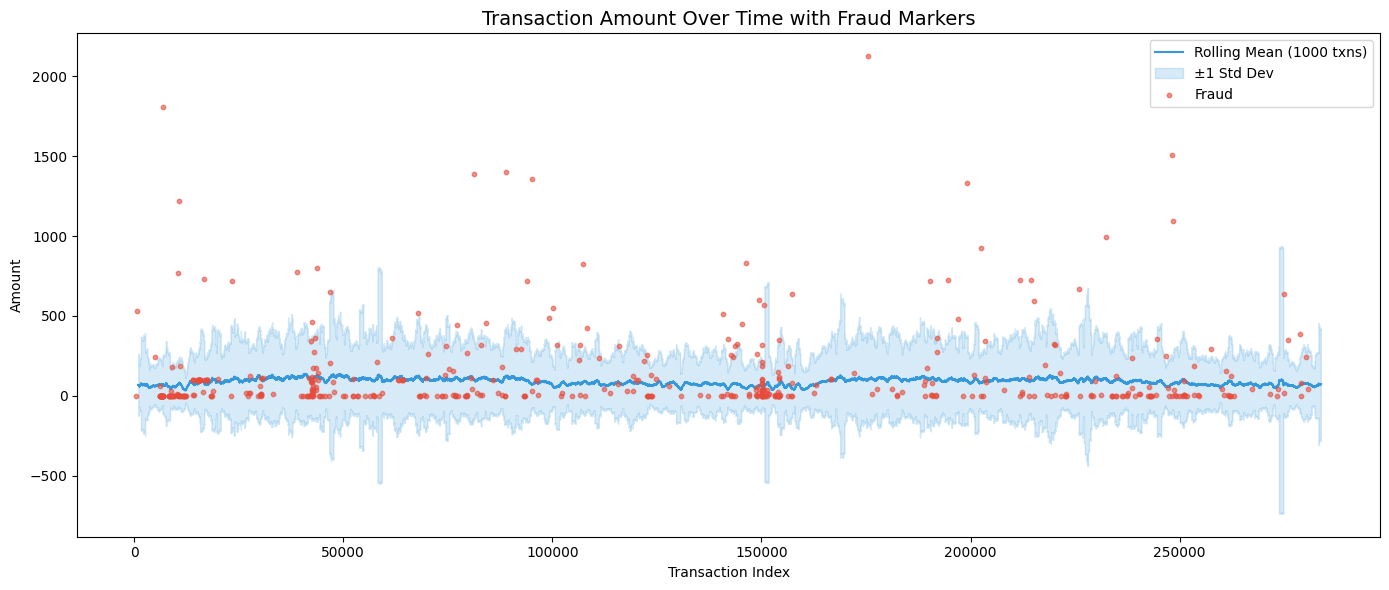

In [ ]:
# Sort by time
df_sorted = df.sort_values('time').reset_index(drop=True)

# Rolling mean & std of amount
df_sorted['rolling_mean'] = df_sorted['amount'].rolling(window=1000).mean()
df_sorted['rolling_std'] = df_sorted['amount'].rolling(window=1000).std()

plt.figure(figsize=(14, 6))
plt.plot(df_sorted.index, df_sorted['rolling_mean'],
         color='#3498db', label='Rolling Mean (1000 txns)', linewidth=1.5)
plt.fill_between(df_sorted.index,
                 df_sorted['rolling_mean'] - df_sorted['rolling_std'],
                 df_sorted['rolling_mean'] + df_sorted['rolling_std'],
                 alpha=0.2, color='#3498db', label='±1 Std Dev')

# Mark fraud transactions
fraud_idx = df_sorted[df_sorted['class'] == 1].index
plt.scatter(fraud_idx, df_sorted.loc[fraud_idx, 'amount'],
            color='#e74c3c', s=10, label='Fraud', zorder=5, alpha=0.6)

plt.title('Transaction Amount Over Time with Fraud Markers', fontsize=14)
plt.xlabel('Transaction Index')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.savefig('charts/rolling_stats.png', dpi=150)
plt.show()

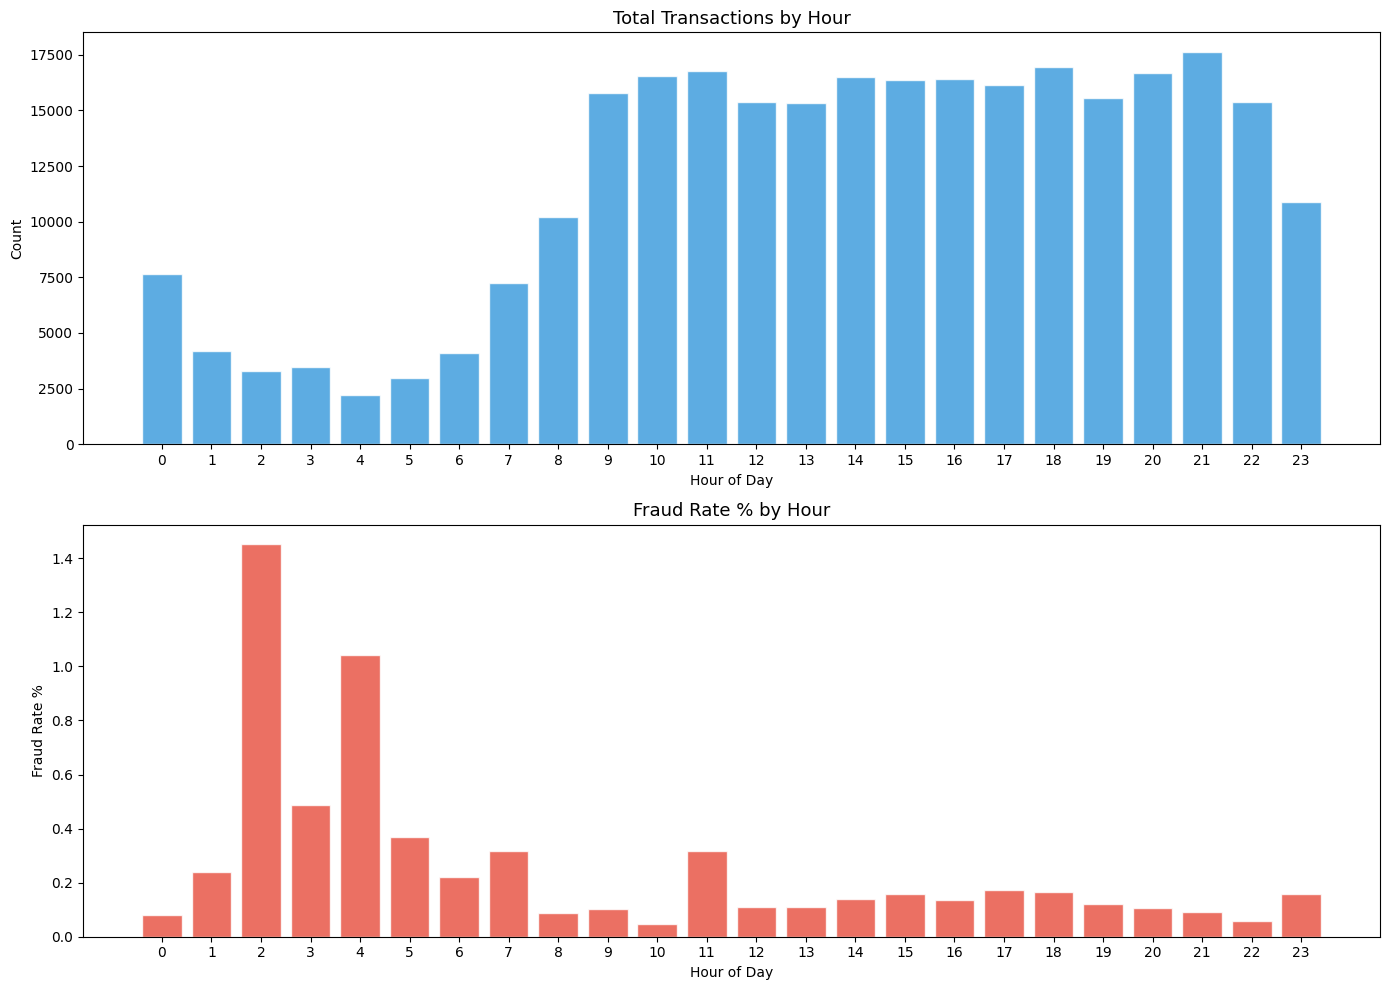


=== TOP 5 HIGHEST FRAUD RATE HOURS ===
   hour  total  fraud  fraud_rate
2     2   3308     48      1.4510
4     4   2204     23      1.0436
3     3   3487     17      0.4875
5     5   2988     11      0.3681
7     7   7233     23      0.3180


In [ ]:
hourly = df.groupby('hour').agg(
    total=('class', 'count'),
    fraud=('class', 'sum')
).reset_index()

hourly['fraud_rate'] = round(hourly['fraud'] / hourly['total'] * 100, 4)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Total transactions by hour
axes[0].bar(hourly['hour'], hourly['total'],
            color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Total Transactions by Hour', fontsize=13)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(24))

# Fraud rate by hour
axes[1].bar(hourly['hour'], hourly['fraud_rate'],
            color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_title('Fraud Rate % by Hour', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate %')
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig('charts/fraud_by_hour.png', dpi=150)
plt.show()

print("\n=== TOP 5 HIGHEST FRAUD RATE HOURS ===")
print(hourly.nlargest(5, 'fraud_rate')[
      ['hour', 'total', 'fraud', 'fraud_rate']])

In [ ]:
# Transactions above 95th percentile
threshold = df['amount'].quantile(0.95)
high_value = df[df['amount'] > threshold]

print(f"=== HIGH VALUE TRANSACTION ANALYSIS ===")
print(f"95th Percentile Threshold: ₹{round(threshold, 2)}")
print(f"High Value Transactions: {len(high_value)}")
print(f"Fraud in High Value: {high_value['class'].sum()}")
print(f"Fraud Rate in High Value: {round(high_value['class'].mean()*100, 4)}%")
print(f"\nNormal Fraud Rate: 0.1727%")
print(f"High Value Fraud Rate: {round(high_value['class'].mean()*100, 4)}%")

diff = high_value['class'].mean()*100 / 0.1727
print(
    f"\n🔥 High value transactions are {round(diff, 1)}x more likely to be fraud!")

=== HIGH VALUE TRANSACTION ANALYSIS ===
95th Percentile Threshold: ₹365.34
High Value Transactions: 14187
Fraud in High Value: 42
Fraud Rate in High Value: 0.296%

Normal Fraud Rate: 0.1727%
High Value Fraud Rate: 0.296%

🔥 High value transactions are 1.7x more likely to be fraud!


In [ ]:
summary = {
    'total_transactions': len(df),
    'total_fraud': df['class'].sum(),
    'fraud_rate_pct': round(df['class'].mean()*100, 4),
    'avg_fraud_amount': round(df[df['class'] == 1]['amount'].mean(), 2),
    'max_fraud_amount': round(df[df['class'] == 1]['amount'].max(), 2),
    'avg_normal_amount': round(df[df['class'] == 0]['amount'].mean(), 2),
    'p_value': round(p_value, 6),
    'hypothesis_result': 'Fraud amounts are statistically different',
    'high_value_threshold': round(threshold, 2),
    'night_fraud_rate': round(df[df['is_night'] == 1]['class'].mean()*100, 4),
    'day_fraud_rate': round(df[df['is_night'] == 0]['class'].mean()*100, 4)
}

summary_df = pd.DataFrame([summary]).T.reset_index()
summary_df.columns = ['metric', 'value']
print("=== PROJECT STATISTICAL SUMMARY ===")
print(summary_df.to_string(index=False))

# Save to CSV for Power BI
summary_df.to_csv('charts/statistical_summary.csv', index=False)
print("\n✅ Summary saved to charts/statistical_summary.csv")

=== PROJECT STATISTICAL SUMMARY ===
              metric                                     value
  total_transactions                                    283726
         total_fraud                                       473
      fraud_rate_pct                                    0.1667
    avg_fraud_amount                                    123.87
    max_fraud_amount                                   2125.87
   avg_normal_amount                                     88.41
             p_value                                   0.00209
   hypothesis_result Fraud amounts are statistically different
high_value_threshold                                    365.34
    night_fraud_rate                                    0.2814
      day_fraud_rate                                    0.1421

✅ Summary saved to charts/statistical_summary.csv
